In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_train = np.load("../data/processed/X_train_balanced.npy")
y_train = np.load("../data/processed/y_train_balanced.npy")
X_test = np.load("../data/processed/X_test_scaled.npy")
y_test = np.load("../data/processed/y_test.npy")

with open("../data/processed/feature_names.txt", "r") as f:
    feature_names = [line.strip() for line in f.readlines()]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (10167052, 13)
Test data shape: (1272524, 13)


In [3]:
model = DecisionTreeClassifier(random_state=42, max_depth=10)  # max_depth to avoid overfitting
model.fit(X_train, y_train)
print("Model training completed.")


Model training completed.


In [4]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))


=== Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.74      1.00      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.87      1.00      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



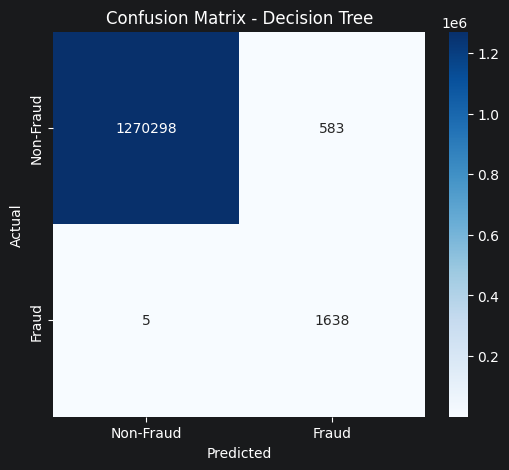

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../data/processed/cm_decision_tree.png")
plt.show()

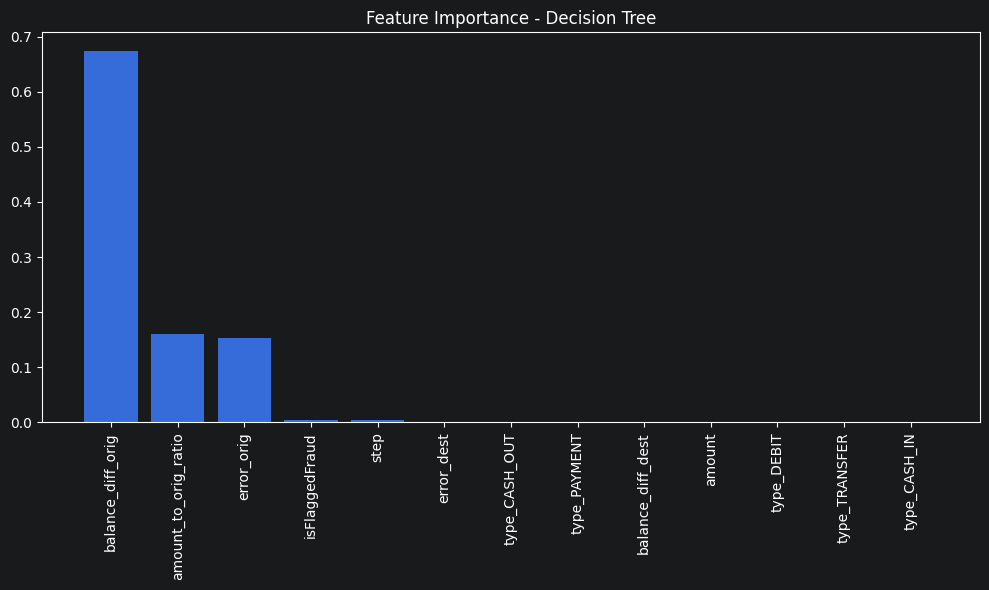

In [6]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.savefig("../data/processed/feature_importance_decision_tree.png")
plt.show()

In [7]:
print("\nTop 5 important features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} (importance: {importances[indices[i]]:.4f})")


Top 5 important features:
1. balance_diff_orig (importance: 0.6741)
2. amount_to_orig_ratio (importance: 0.1598)
3. error_orig (importance: 0.1539)
4. isFlaggedFraud (importance: 0.0048)
5. step (importance: 0.0036)


In [8]:
joblib.dump(model, "../models/decision_tree.pkl")
print("✅ Model saved as ../models/decision_tree.pkl")


✅ Model saved as ../models/decision_tree.pkl
